# Predictor — LSTM vs GRU (MSFT)

Microsoft hissesinin son 20 gününe bakarak ertesi günün kapanış fiyatını tahmin eden
iki tekrarlayan sinir ağının karşılaştırması: LSTM ve GRU. İki model de aynı veri,
aynı hiperparametreler ve aynı rastgele başlangıçla eğitiliyor.

**Veri:** Yahoo Finance, MSFT günlük fiyatları, 2014-2026 (3018 işlem günü).

**Girdi:** `Open`, `High`, `Low`, `Close`, `Volume` — beş sütun.

**Hedef:** Ertesi günün `Close` değeri. Tek çıktılı regresyon.

## 1. Kurulum ve importlar

In [7]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from data import (download_data, scale_features, scale_target,
                  create_sliding_windows, train_test_split_sequences,
                  FEATURE_COLUMNS, TARGET_COLUMN)
from models import LSTMModel, GRUModel
from train import train_model
from evaluate import evaluate_model, plot_predictions

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Girdi ozellikleri:", FEATURE_COLUMNS)
print("Hedef:", TARGET_COLUMN)

Device: cuda
Girdi ozellikleri: ['Open', 'High', 'Low', 'Close', 'Volume']
Hedef: Close


## 2. Veri toplama

Veri `yfinance` ile çekiliyor ve `data/MSFT.csv` olarak kaydediliyor. Notebook'un
baştan sona çalışabilmesi için indirme her seferinde tekrarlanıyor.

In [8]:
df = download_data(ticker="MSFT", start="2014-01-01", end="2026-01-01",
                    save_path="../data/MSFT.csv")
print(df.shape)
df.head()

(3018, 6)


Price,Date,Close,High,Low,Open,Volume
0,2014-01-02,30.636770,30.834641,30.587302,30.793416,30632200
1,2014-01-03,30.430662,30.686245,30.175080,30.669755,31134800
2,2014-01-06,29.787577,30.414161,29.771087,30.381182,43603700
3,2014-01-07,30.018421,30.084379,29.853529,29.952466,35802800
4,2014-01-08,29.482529,29.795823,29.334130,29.680399,59971700


In [9]:
df[FEATURE_COLUMNS].describe()

Price,Open,High,Low,Close,Volume
count,3018.000000,3018.000000,3018.000000,3018.000000,3.018000e+03
mean,190.694464,192.457863,188.843219,190.736226,2.869731e+07
std,144.161153,145.345423,142.857234,144.148021,1.351486e+07
min,28.633336,29.581461,28.550892,28.839457,5.855900e+06
25%,56.051676,56.400314,55.680675,56.006966,2.031285e+07
50%,143.536108,146.615930,142.434816,144.244217,2.561085e+07
75%,292.287046,295.936615,289.072371,292.503235,3.310390e+07
max,549.795235,550.013114,536.357044,537.646423,2.025224e+08


## 3. Keşifsel veri analizi

Fiyatlar 30-550 dolar aralığında, işlem hacmi ise milyonlar mertebesinde. Ölçek farkı
nedeniyle ikisi ayrı eksenlerde çiziliyor.

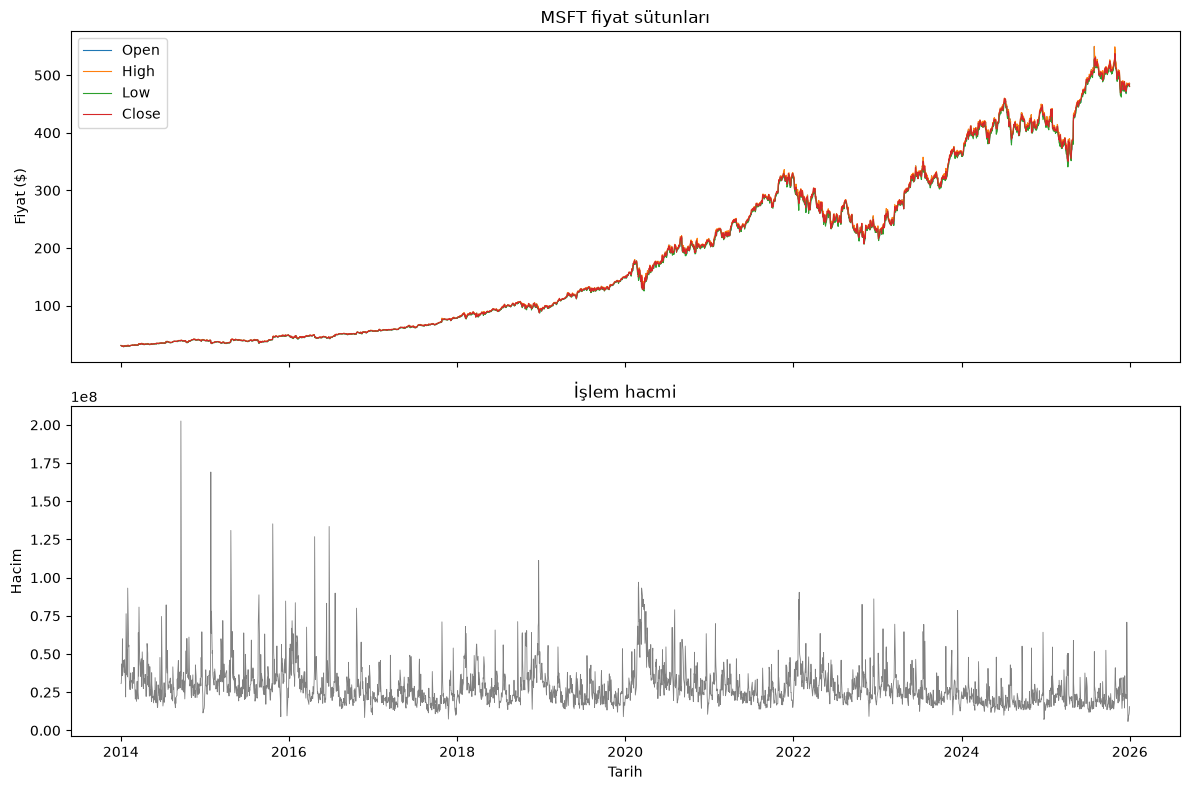

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for col in ["Open", "High", "Low", "Close"]:
    axes[0].plot(df["Date"], df[col], label=col, linewidth=0.8)
axes[0].set_title("MSFT fiyat sütunları")
axes[0].set_ylabel("Fiyat ($)")
axes[0].legend()

axes[1].plot(df["Date"], df["Volume"], color="gray", linewidth=0.6)
axes[1].set_title("İşlem hacmi")
axes[1].set_ylabel("Hacim")
axes[1].set_xlabel("Tarih")

plt.tight_layout()
plt.savefig("../results/msft_features.png", dpi=100)
plt.show()

### Özellikler arası korelasyon

Modele beş sütun veriliyor. Bu sütunların ne kadar bağımsız bilgi taşıdığı korelasyon
matrisinden görülebilir.

In [11]:
# 4 basamak: 3'te fiyat sutunlari 1.000 gorunup ayirt edilemiyor
kor = df[FEATURE_COLUMNS].corr().round(4)
kor.columns.name = None
kor.index.name = None
kor

,Open,High,Low,Close,Volume
Open,1.0000,0.9999,0.9999,0.9998,-0.2390
High,0.9999,1.0000,0.9999,0.9999,-0.2357
Low,0.9999,0.9999,1.0000,0.9999,-0.2431
Close,0.9998,0.9999,0.9999,1.0000,-0.2399
Volume,-0.2390,-0.2357,-0.2431,-0.2399,1.0000


Fiyat sütunlarının birbiriyle korelasyonu 1.00'e çok yakın; biri bilindiğinde
diğerleri hakkında yeni bir bilgi kalmıyor. `Volume` ise fiyat sütunlarıyla zayıf
ilişkili.

Bu tablo, 9. bölümdeki özellik seçimi deneyinin sonucunu açıklarken kullanılacak.

## 4. Ön işleme

Ölçekleme iki ayrı `MinMaxScaler` ile yapılıyor.

Birincisi beş girdi sütununu ölçekliyor. Her sütun kendi min/max değerine göre
ölçeklendiği için `Volume` (~10⁸) fiyat sütunlarını (~10²) baskılamıyor.

İkincisi yalnızca `Close` üzerine kuruluyor. Bu ayrım zorunlu: model tek bir sayı
üretiyor ve bu değerin dolara geri çevrilmesi gerekiyor. Beş sütuna göre kurulmuş bir
scaler tersine dönüşümde hangi sütunun ölçeğini kullanacağını belirleyemez.

In [12]:
LOOKBACK = 20
TRAIN_RATIO = 0.8

features, feature_scaler = scale_features(df, feature_range=(-1, 1))
target, target_scaler = scale_target(df, feature_range=(-1, 1))

print("features:", features.shape, "-> (gun, ozellik)")
print("target  :", target.shape)

features: (3018, 5) -> (gun, ozellik)
target  : (3018, 1)


Veri 20 günlük kayan pencerelere bölünüyor. Her pencere bir eğitim örneği oluşturuyor:
20 günün beş sütunu girdi, 21. günün kapanışı hedef.

Bölme işleminde karıştırma yapılmıyor. Zaman serilerinde ilk %80 eğitim, son %20 test
olarak ayrılmalı. Karıştırma durumunda model gelecekteki verilerle eğitilip geçmişi
tahmin etmeye çalışır ve sonuç geçersiz hale gelir.

In [13]:
X, y = create_sliding_windows(features, target, lookback=LOOKBACK)
X_train, X_test, y_train, y_test = train_test_split_sequences(X, y, train_ratio=TRAIN_RATIO)

print("X_train:", X_train.shape, "-> (ornek, lookback, ozellik)")
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (2398, 20, 5) -> (ornek, lookback, ozellik)
y_train: (2398, 1)
X_test : (600, 20, 5)
y_test : (600, 1)


In [14]:
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float().reshape(-1, 1)
X_test_t = torch.from_numpy(X_test).float()

print(X_train_t.shape, y_train_t.shape, X_test_t.shape)

torch.Size([2398, 20, 5]) torch.Size([2398, 1]) torch.Size([600, 20, 5])


### Model mimarisi

Her iki sınıf da `src/models.py` içinde tanımlı. İskelet ortak:

```python
class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=2, output_size=1, dropout=0.0):
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=...)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])
```

`h0` gizli durumu, `c0` hücre durumunu tutar. Her pencere için ikisi de sıfırlanıyor;
böylece bir önceki pencereden kalan bilgi sonrakine taşınmıyor.

`new_zeros` kullanılmasının nedeni cihaz uyumu: oluşturulan tensörler girdiyle aynı
cihazda (CPU veya GPU) yer alıyor.

`out[:, -1, :]` ifadesi son zaman adımının çıktısını seçiyor. LSTM 20 adımın her biri
için çıktı üretir, ancak tahmin için yalnızca tüm pencere işlendikten sonraki durum
kullanılıyor. Bu çıktı `Linear` katmanıyla tek değere indirgeniyor.

GRU'da hücre durumu bulunmadığından yalnızca `h0` gerekiyor. Daha az kapı, daha az
parametre demek; eğitim süresi de buna bağlı olarak kısalıyor.

## 5. Model tanımları

İki modele de aynı hiperparametreler veriliyor. Farklı ayarlar kullanılsaydı performans
farkının mimariden mi yoksa hiperparametre seçiminden mi kaynaklandığı ayırt
edilemezdi.

In [15]:
N_FEATURES = len(FEATURE_COLUMNS)
HIDDEN_SIZE = 32
NUM_LAYERS = 2
EPOCHS = 100
LR = 0.01

lstm_model = LSTMModel(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE,
                        num_layers=NUM_LAYERS, output_size=1)
gru_model = GRUModel(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE,
                      num_layers=NUM_LAYERS, output_size=1)

n_lstm = sum(p.numel() for p in lstm_model.parameters())
n_gru = sum(p.numel() for p in gru_model.parameters())
print(f"LSTM parametre sayisi: {n_lstm}")
print(f"GRU  parametre sayisi: {n_gru}")

LSTM parametre sayisi: 13473
GRU  parametre sayisi: 10113


Parametre sayısındaki fark, GRU'nun daha az kapı içermesinden kaynaklanıyor.

## 6. Eğitim

In [16]:
print("--- LSTM ---")
lstm_model, lstm_history, lstm_time = train_model(
    lstm_model, X_train_t, y_train_t, epochs=EPOCHS, lr=LR, device=DEVICE
)

--- LSTM ---
Epoch 10/100 - Loss: 0.067152
Epoch 20/100 - Loss: 0.016550
Epoch 30/100 - Loss: 0.003642
Epoch 40/100 - Loss: 0.002896
Epoch 50/100 - Loss: 0.001372
Epoch 60/100 - Loss: 0.000810
Epoch 70/100 - Loss: 0.000597
Epoch 80/100 - Loss: 0.000450
Epoch 90/100 - Loss: 0.000376
Epoch 100/100 - Loss: 0.000358
Training completed in 0.84s


In [17]:
print("--- GRU ---")
gru_model, gru_history, gru_time = train_model(
    gru_model, X_train_t, y_train_t, epochs=EPOCHS, lr=LR, device=DEVICE
)

--- GRU ---
Epoch 10/100 - Loss: 0.027100
Epoch 20/100 - Loss: 0.002226
Epoch 30/100 - Loss: 0.003147
Epoch 40/100 - Loss: 0.001902
Epoch 50/100 - Loss: 0.000594
Epoch 60/100 - Loss: 0.000384
Epoch 70/100 - Loss: 0.000313
Epoch 80/100 - Loss: 0.000271
Epoch 90/100 - Loss: 0.000250
Epoch 100/100 - Loss: 0.000240
Training completed in 0.69s


Kayıp değeri düzenli olarak azalıyor. Grafik logaritmik eksende çiziliyor; kayıp
0.06'dan 0.0003'e indiği için doğrusal eksende son iterasyonlardaki iyileşme
görünmez olurdu.

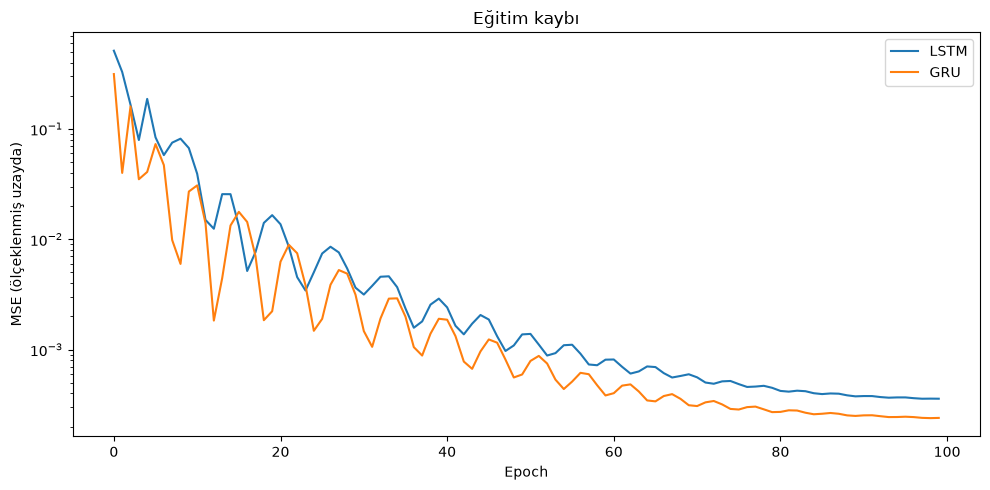

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_history, label="LSTM")
plt.plot(gru_history, label="GRU")
plt.yscale("log")
plt.title("Eğitim kaybı")
plt.xlabel("Epoch")
plt.ylabel("MSE (ölçeklenmiş uzayda)")
plt.legend()
plt.tight_layout()
plt.savefig("../results/training_loss.png", dpi=100)
plt.show()

## 7. Değerlendirme

Modeller test kümesinde (son %20) tahmin üretiyor. Tahminler ölçeklenmiş uzayda
çıktığı için `inverse_transform` ile dolara çevriliyor; hata metrikleri bu şekilde
yorumlanabilir bir birime kavuşuyor.

In [20]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(X_test_t.to(DEVICE)).cpu().numpy()
    gru_preds = gru_model(X_test_t.to(DEVICE)).cpu().numpy()

lstm_metrics = evaluate_model(y_test, lstm_preds, target_scaler)
gru_metrics = evaluate_model(y_test, gru_preds, target_scaler)

print(f"LSTM -> MSE: {lstm_metrics['mse']:.4f}  RMSE: {lstm_metrics['rmse']:.4f}  Sure: {lstm_time:.2f}s")
print(f"GRU  -> MSE: {gru_metrics['mse']:.4f}  RMSE: {gru_metrics['rmse']:.4f}  Sure: {gru_time:.2f}s")

LSTM -> MSE: 3370.5300  RMSE: 58.0563  Sure: 0.84s
GRU  -> MSE: 1758.7726  RMSE: 41.9377  Sure: 0.69s


In [21]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [lstm_metrics["mse"], gru_metrics["mse"]],
    "RMSE": [lstm_metrics["rmse"], gru_metrics["rmse"]],
    "Training Time (s)": [lstm_time, gru_time],
})
comparison.to_csv("../results/model_comparison.csv", index=False)
comparison

,Model,MSE,RMSE,Training Time (s)
0,LSTM,3370.529977,58.056266,0.841816
1,GRU,1758.772553,41.937722,0.694445


### Eğitim ve test hatası

Eğitim kaybının azalması tek başına genelleme başarısını göstermez. Model eğitim
verisini ezberlemiş de olabilir. Ayrım için aynı modeller hem eğitim hem test
kümesinde ölçülüyor.

In [22]:
rows = []
for name, model in [("LSTM", lstm_model), ("GRU", gru_model)]:
    with torch.no_grad():
        p_train = model(X_train_t.to(DEVICE)).cpu().numpy()
        p_test = model(X_test_t.to(DEVICE)).cpu().numpy()
    tr = evaluate_model(y_train, p_train, target_scaler)
    te = evaluate_model(y_test, p_test, target_scaler)
    rows.append({
        "Model": name,
        "Train MSE": tr["mse"], "Test MSE": te["mse"],
        "Train RMSE": tr["rmse"], "Test RMSE": te["rmse"],
        "Test/Train": te["rmse"] / tr["rmse"],
    })

overfit = pd.DataFrame(rows)
overfit.to_csv("../results/train_vs_test.csv", index=False)
overfit.round(3)

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Test/Train
0,LSTM,22.929,3370.530,4.788,58.056,12.124
1,GRU,15.504,1758.773,3.938,41.938,10.651


Eğitim ve test hataları arasında 10 kattan fazla fark var. Model eğitim verisinde
4-5 dolar, test verisinde 40-58 dolar sapma gösteriyor. Bu tablo aşırı öğrenmeye
(overfitting) işaret ediyor.

Oranın 1'e yakın olması genellemenin başarılı olduğu anlamına gelirdi.

## 8. Tahmin görselleştirmesi

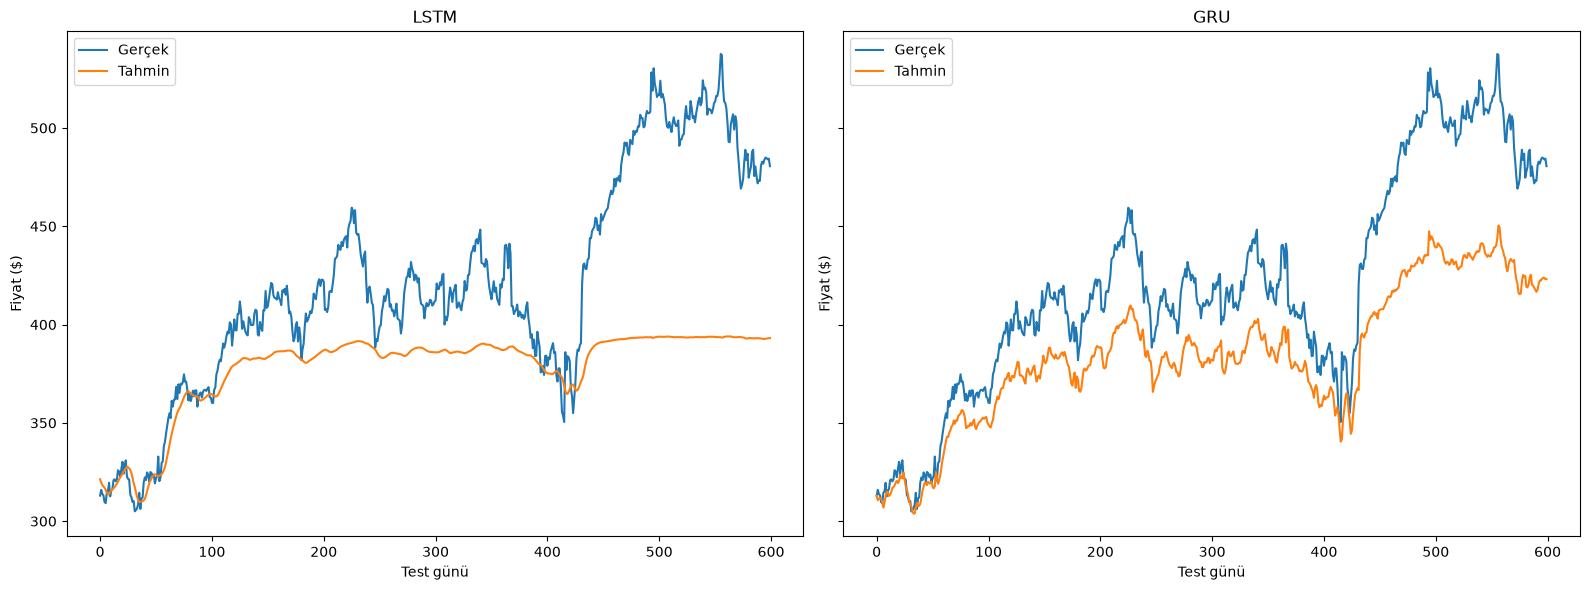

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_predictions(lstm_metrics["y_true"], lstm_metrics["y_pred"],
                 title="LSTM", ax=axes[0])
plot_predictions(gru_metrics["y_true"], gru_metrics["y_pred"],
                 title="GRU", ax=axes[1])
plt.tight_layout()
plt.savefig("../results/predictions_comparison.png", dpi=100)
plt.show()

Grafikte tahmin ve gerçek eğriler birbirine çok yakın görünüyor, ancak bu görüntü
yanıltıcı.

Günlük fiyat değişimi %1-2 mertebesindeyken grafiğin ekseni 300-550 dolar aralığını
kapsıyor. Bu ölçekte, ertesi günün fiyatını bugünkü fiyata eşitleyen bir model bile
benzer bir görüntü üretir. Modeller arasındaki gerçek fark RMSE tablosunda
görülüyor.

## 9. Özellik seçimi deneyi (ablation)

Modele OHLCV sütunlarının tamamı veriliyor. Korelasyon matrisi bu sütunların büyük
ölçüde aynı bilgiyi taşıdığını gösterdiğine göre, hepsini kullanmanın katkısı ölçülmeli.

Yalnızca `Close` kullanan kurulum ile beş sütunlu kurulum karşılaştırılıyor.
Hiperparametreler ve rastgele başlangıç sabit; değişen tek şey girdi sütunları.

In [24]:
def run_setup(feature_cols, label):
    feats, _ = scale_features(df, feature_cols)
    Xs, ys = create_sliding_windows(feats, target, lookback=LOOKBACK)
    Xtr, Xte, ytr, yte = train_test_split_sequences(Xs, ys, TRAIN_RATIO)
    Xtr_t = torch.from_numpy(Xtr).float()
    ytr_t = torch.from_numpy(ytr).float().reshape(-1, 1)
    Xte_t = torch.from_numpy(Xte).float()

    rows = []
    for name, cls in [("LSTM", LSTMModel), ("GRU", GRUModel)]:
        torch.manual_seed(42)
        np.random.seed(42)
        m = cls(input_size=len(feature_cols), hidden_size=HIDDEN_SIZE,
                num_layers=NUM_LAYERS, output_size=1)
        m, _, el = train_model(m, Xtr_t, ytr_t, epochs=EPOCHS, lr=LR,
                                device=DEVICE, verbose=False)
        m.eval()
        with torch.no_grad():
            p = m(Xte_t.to(DEVICE)).cpu().numpy()
        mt = evaluate_model(yte, p, target_scaler)
        rows.append({"Kurulum": label, "Model": name,
                     "RMSE": mt["rmse"], "Sure (s)": el})
    return rows


ablation = pd.DataFrame(
    run_setup(["Close"], "Tek degiskenli (Close)")
    + run_setup(FEATURE_COLUMNS, "Cok degiskenli (OHLCV)")
)
ablation.to_csv("../results/feature_ablation.csv", index=False)
ablation

,Kurulum,Model,RMSE,Sure (s)
0,Tek degiskenli (Close),LSTM,46.032181,0.772758
1,Tek degiskenli (Close),GRU,22.968343,0.500155
2,Cok degiskenli (OHLCV),LSTM,58.056266,0.521760
3,Cok degiskenli (OHLCV),GRU,47.987746,0.498589


Sonuç beklenenin tersi: yalnızca `Close` kullanan kurulum daha düşük hata veriyor.

Nedeni korelasyon tablosunda görülüyor. `Open`, `High` ve `Low` sütunlarının `Close`
ile korelasyonu 0.999 seviyesinde, yani modele kayda değer yeni bilgi eklemiyorlar.
`Volume` ise fiyatla zayıf ilişkili. Buna karşılık girdi boyutunun 1'den 5'e çıkması
öğrenilmesi gereken parametre sayısını artırıyor ve model aynı epoch bütçesinde bu
yükü karşılayamıyor.

## 10. Hiperparametre denemeleri

Aşırı öğrenme tespit edildiği için üç yönde deneme yapılıyor: pencere uzunluğu,
model kapasitesi ve dropout.

Her kurulum sıfırdan eğitiliyor, rastgele başlangıç sabit tutuluyor. Karşılaştırma
ölçütü test RMSE değeri.

In [25]:
def dene(lookback_=LOOKBACK, hidden=HIDDEN_SIZE, dropout=0.0, etiket=""):
    feats, _ = scale_features(df, FEATURE_COLUMNS)
    Xs, ys = create_sliding_windows(feats, target, lookback=lookback_)
    Xtr, Xte, ytr, yte = train_test_split_sequences(Xs, ys, TRAIN_RATIO)

    Xtr_t = torch.from_numpy(Xtr).float()
    ytr_t = torch.from_numpy(ytr).float().reshape(-1, 1)
    Xte_t = torch.from_numpy(Xte).float()

    out = []
    for ad, cls in [("LSTM", LSTMModel), ("GRU", GRUModel)]:
        torch.manual_seed(42)
        np.random.seed(42)
        m = cls(input_size=len(FEATURE_COLUMNS), hidden_size=hidden,
                num_layers=NUM_LAYERS, output_size=1, dropout=dropout)
        m, _, _ = train_model(m, Xtr_t, ytr_t, epochs=EPOCHS, lr=LR,
                              device=DEVICE, verbose=False)
        m.eval()
        with torch.no_grad():
            p_te = m(Xte_t.to(DEVICE)).cpu().numpy()
            p_tr = m(Xtr_t.to(DEVICE)).cpu().numpy()
        te = evaluate_model(yte, p_te, target_scaler)
        tr = evaluate_model(ytr, p_tr, target_scaler)
        out.append({"Kurulum": etiket, "Model": ad,
                    "Test RMSE": te["rmse"], "Train RMSE": tr["rmse"],
                    "Test/Train": te["rmse"] / tr["rmse"]})
    return out


denemeler = []
denemeler += dene(etiket="temel (lookback=20, hidden=32)")
denemeler += dene(lookback_=10, etiket="lookback=10")
denemeler += dene(lookback_=40, etiket="lookback=40")
denemeler += dene(hidden=16, etiket="hidden=16 (daha kucuk)")
denemeler += dene(dropout=0.2, etiket="dropout=0.2")

tuning = pd.DataFrame(denemeler)
tuning.to_csv("../results/hyperparameter_tuning.csv", index=False)
tuning.round(2)

,Kurulum,Model,Test RMSE,Train RMSE,Test/Train
0,"temel (lookback=20, hidden=32)",LSTM,58.06,4.79,12.12
1,"temel (lookback=20, hidden=32)",GRU,47.99,4.49,10.68
2,lookback=10,LSTM,59.09,4.96,11.92
3,lookback=10,GRU,47.85,4.99,9.59
4,lookback=40,LSTM,56.71,4.76,11.92
5,lookback=40,GRU,47.81,4.43,10.80
6,hidden=16 (daha kucuk),LSTM,69.24,4.71,14.70
7,hidden=16 (daha kucuk),GRU,24.67,4.60,5.36
8,dropout=0.2,LSTM,62.55,5.07,12.33
9,dropout=0.2,GRU,46.28,5.20,8.90


In [26]:
en_iyi = tuning.loc[tuning["Test RMSE"].idxmin()]
temel = tuning[tuning["Kurulum"].str.startswith("temel")]["Test RMSE"].min()

print(f"En iyi kurulum : {en_iyi['Kurulum']} / {en_iyi['Model']}")
print(f"Test RMSE      : ${en_iyi['Test RMSE']:.2f}")
print(f"Temel kuruluma gore degisim: {(en_iyi['Test RMSE'] - temel) / temel * 100:+.1f}%")

En iyi kurulum : hidden=16 (daha kucuk) / GRU
Test RMSE      : $24.67
Temel kuruluma gore degisim: -48.6%


En belirgin iyileşme model kapasitesinin azaltılmasından geldi. `hidden_size`
değerinin 32'den 16'ya indirilmesiyle GRU'nun test hatası yarıya düştü, eğitim/test
oranı da 10.7'den 5.4'e geriledi.

Bu sonuç modelin veri setine göre fazla büyük olduğunu gösteriyor. Kapasite
sınırlandığında ezberleme imkanı azalıyor ve model genellemeye yöneliyor.

Dropout aynı yönde etki etti ancak katkısı daha sınırlı kaldı. Pencere uzunluğundaki
değişiklikler sonucu belirgin biçimde etkilemedi.

Aynı küçültme LSTM'de ters etki yaptı. LSTM'in ek kapı yapısı daha fazla parametre
gerektirdiğinden 16 birimlik gizli katman yetersiz kalıyor.

## 11. Karşılaşılan teknik sorunlar

**Bozuk sanal ortam.** Paket dosyaları mevcuttu ancak metadata bilgileri eksikti;
`import numpy` çalışırken `numpy.__version__` erişilemiyordu. Ortamın sıfırdan
kurulması gerekti.

**GPU'nun tanınmaması.** `torch.cuda.is_available()` sürekli `False` döndürüyordu.
Donanım ve sürücü sorunsuzdu; sorun PyPI üzerinden gelen torch paketinin CPU-only
derleme olmasından kaynaklanıyordu. CUDA sürümünün ayrı indeksten kurulmasıyla
çözüldü. Kurulum sırasında iki kesinti yaşandı: bağımlılık çözümünde kilitlenme ve
indirmenin kopması.

**Kernel önbelleği.** `src/` altındaki dosyalar değiştirildikten sonra notebook
`ImportError` verdi. Python içe aktarılan modülleri bellekte tuttuğu için dosya
değişikliği tek başına yeterli olmuyor; kernel yeniden başlatılmalı.

**Tarih aralığı değişiminin etkisi.** Veri aralığı 2012-2024'ten 2014-2026'ya
alındığında RMSE 5.2'den 11.5'e yükseldi. Kodda hata bulunmadı; fiyat seviyesinin
yükselmesi dolar cinsinden hatayı da büyütmüştü. RMSE'nin mutlak değerinin tek başına
yorumlanamayacağını gösteren bir örnek.

**Özellik sayısının beklenmedik etkisi.** Beş sütun kullanmanın sonucu iyileştireceği
öngörülmüştü; ölçüm bunun tersini gösterdi.

## 12. Çıkarımlar

Bu çalışmanın en somut dersi ölçüm disiplini oldu. Eğitim kaybı eğrisi modelin
öğrendiğini söylüyordu, test hatası tersini gösterdi. Doğru olan ikincisiydi; bir
modelin başarısı yalnızca görmediği veri üzerinden konuşulabiliyor.

İkincisi özellik seçimiyle ilgili. Daha fazla sütun sezgisel olarak daha fazla bilgi
anlamına geliyor, ama 9. bölümdeki deney bu varsayımı çürüttü.

Model kapasitesinde de benzer bir durum var. Küçültmenin sonucu iyileştirmesi beklenen
bir davranış değil.

Metriklerin birimi ayrı bir dikkat noktası: ölçeklenmiş uzaydaki kayıp ile dolar
cinsinden RMSE aynı büyüklüğün iki farklı gösterimi.

## 13. Sınırlamalar

Ölçekleyici train/test ayrımından önce veri setinin tamamına uygulanıyor. Referans
alınan çalışma da bu yaklaşımı kullanıyor, ancak yöntem olarak doğru değil: test
kümesinin min/max bilgisi eğitime sızıyor. Düzeltilmesi durumunda raporlanan hata
değerleri bir miktar yükselir.

Hisse senedi fiyat tahmini zorlu bir problem. Piyasalar haber akışı, makroekonomik
gelişmeler ve yatırımcı davranışından etkileniyor; geçmiş fiyat örüntüleri geleceği
belirlemiyor. 7. bölümdeki eğitim/test farkı bunun sayısal karşılığı.

Narayanan ve Kapoor'un *AI Snake Oil* çalışması tam da bu ayrımı konu ediyor:
etkileyici görünen çıktılar ile gerçek tahmin gücü aynı şey değil.

Bu bir öğrenme projesi, yatırım tavsiyesi değil.

## 14. Geliştirme önerileri

Türetilmiş göstergeler (hareketli ortalama, RSI) ham OHLCV sütunlarının aksine yeni
bilgi taşıyabilir.

Erken durdurma, doğrulama hatası yükselmeye başladığında eğitimi keserek aşırı
öğrenmeyi sınırlayabilir.

Ölçekleyicinin yalnızca eğitim kümesine uygulanması veri sızıntısını giderir.